# RRL CW1 – Dynamic Programming (Value Iteration)
Notebook version of your provided DP script.


## 1. Imports

In [1]:
import numpy as np
from gymnasium.wrappers import TimeLimit
from my_cartpole_env import CartPoleEnv
from plotting import *
from common import *
from hyperparameters import *

In [2]:
np.linspace(0,1,5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

## 2. Value Iteration

In [3]:
def value_iteration(c1=CART_COST_WEIGHT,c2=POLE_ANGLE_COST_WEIGHT,GAMMA=GAMMA):
    global V
    current_state_costs = quadratic_cost(state_tensor,c1,c2)
    for it in range(N_ITERATIONS):
        V_old = V.copy()
        V_new = []
        for action in ACTION_VALS:
            next_states = dynamics(state_tensor, action)
            next_indices = state_to_indices(next_states, [x_vals, x_dot_vals, theta_vals, theta_dot_vals])
            future_val = current_state_costs + GAMMA * V_old[next_indices]
            new_estimate = np.where(is_terminal[next_indices], TERMINAL_COST, future_val)
            V_new.append(new_estimate)
        V = np.min(V_new, axis=0)
        diff = np.max(np.abs(V - V_old))
        print(f"[{it}] diff = {diff:.5f}", end='\r')
        if diff < DELTA:
            print(f"\nVI completed in {it} iterations")
            break
    return V

## 3. Policy Extraction

In [4]:
def compute_policy(V, c1=CART_COST_WEIGHT, c2=POLE_ANGLE_COST_WEIGHT, GAMMA=GAMMA):
    current_cost = quadratic_cost(state_tensor, c1, c2)

    q_vals = []
    for action in ACTION_VALS:
        ns   = dynamics(state_tensor, action)
        idx  = state_to_indices(ns, [x_vals, x_dot_vals, theta_vals, theta_dot_vals])
        term = is_terminal[idx]
        fv   = np.where(term, TERMINAL_COST, V[idx])
        q_vals.append(current_cost + GAMMA * fv)

    q0, q1 = q_vals[0], q_vals[1]

    # don't cast to int
    policy = np.argmin(np.stack([q0, q1], axis=0), axis=0).astype(float)

    tie = np.isclose(q0, q1, rtol=1e-5, atol=1e-8)

    # stats only for xdot≈0 and thetadot≈0 (in the full 4D policy)
    xdot0_idx = np.argmin(np.abs(x_dot_vals - 0.0))
    tdot0_idx = np.argmin(np.abs(theta_dot_vals - 0.0))

    # NOTE: policy isn't defined yet if you print before creating it,
    # so compute it first:
    policy = np.argmin(np.stack([q0, q1], axis=0), axis=0).astype(float)

    pol_00 = policy[:, xdot0_idx, :, tdot0_idx]
    tie_00 = tie[:, xdot0_idx, :, tdot0_idx]

    print("tie fraction (xdot≈0, thetadot≈0):", tie_00.mean())

    non_tie = ~tie_00
    if non_tie.any():
        print("a0 fraction (non-tie, xdot≈0, thetadot≈0):", (pol_00[non_tie] == 0).mean())
        print("a1 fraction (non-tie, xdot≈0, thetadot≈0):", (pol_00[non_tie] == 1).mean())
    else:
        print("No non-tie states in this subset.")

    policy[tie] = 0.5
    return policy


# Problem 1(a) – Effect of Gamma


--- Gamma = 0.5 ---
[7] diff = 0.00781
VI completed in 7 iterations
tie fraction (xdot≈0, thetadot≈0): 1.0
No non-tie states in this subset.
unique values in p_slice: [0.5]
dtype: float64


ValueError: 'managua' is not a valid value for cmap; supported values are 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Grays', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm',

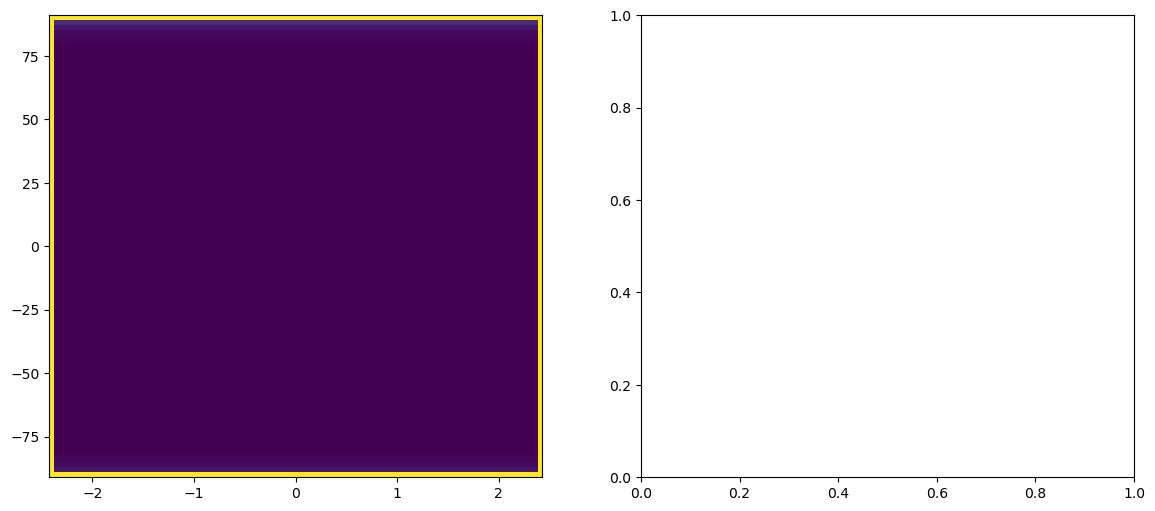

In [5]:
for gamma in [0.5, 0.9, 0.99, 0.999]:
    print(f"\n--- Gamma = {gamma} ---")
    V = value_iteration(c1=0,c2=0,GAMMA=gamma)
    policy = compute_policy(V, GAMMA=gamma)

    plot_policy_value(policy, V, N_BINS, x_vals, theta_vals)
    # plot_3d_slice(policy,
    #           x_vals, x_dot_vals, theta_vals, theta_dot_vals,
    #           fixed_var="x",
    #           fixed_value=0.0,
    #           is_policy=True)
    
    # plot_3d_slice_interactive(policy, x_vals, x_dot_vals, theta_vals, theta_dot_vals, fixed_var="x", fixed_value=0.0, is_policy=True)





### Answer 1(a)
_Write your explanation here._

# Problem 1(b) – Dense Quadratic Costs


--- c1 = 0.1, c2 = 0.1 ---
[85] diff = 0.00879
VI completed in 85 iterations
tie fraction (xdot≈0, thetadot≈0): 0.14555555555555555
a0 fraction (non-tie, xdot≈0, thetadot≈0): 0.45253576072821844
a1 fraction (non-tie, xdot≈0, thetadot≈0): 0.5474642392717816
unique values in p_slice: [0.  0.5 1. ]
dtype: float64


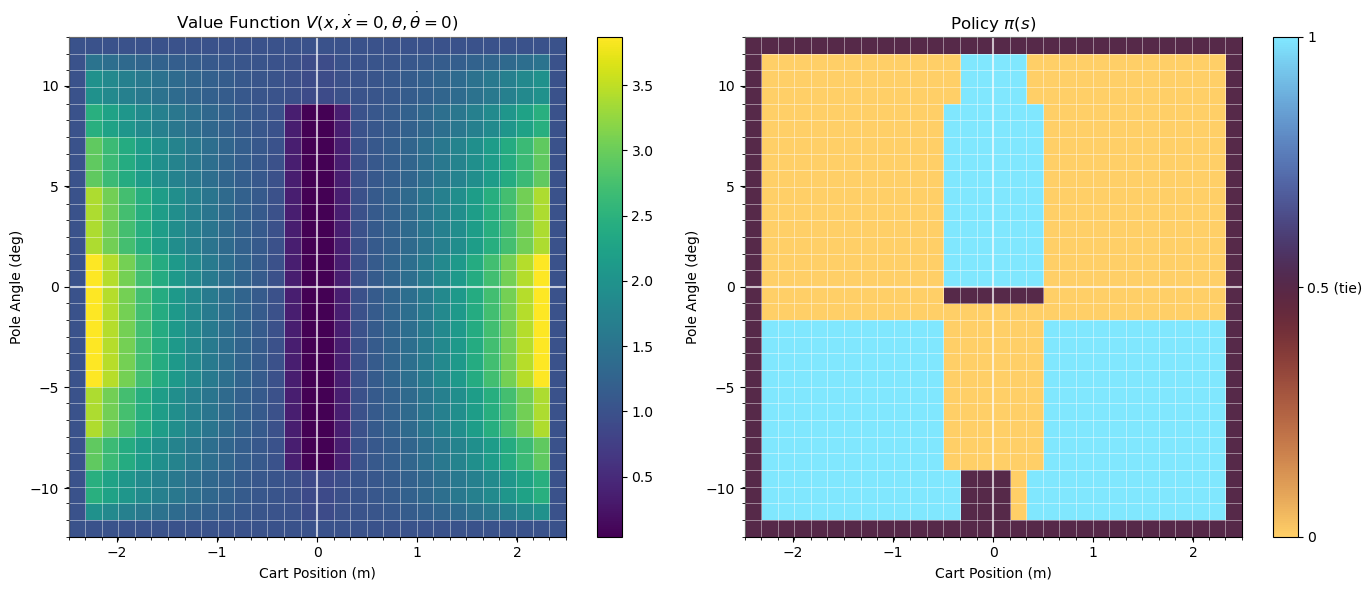


--- c1 = 0.01, c2 = 0.01 ---
[116] diff = 0.00997
VI completed in 116 iterations
tie fraction (xdot≈0, thetadot≈0): 0.1811111111111111
a0 fraction (non-tie, xdot≈0, thetadot≈0): 0.48846675712347354
a1 fraction (non-tie, xdot≈0, thetadot≈0): 0.5115332428765265
unique values in p_slice: [0.  0.5 1. ]
dtype: float64


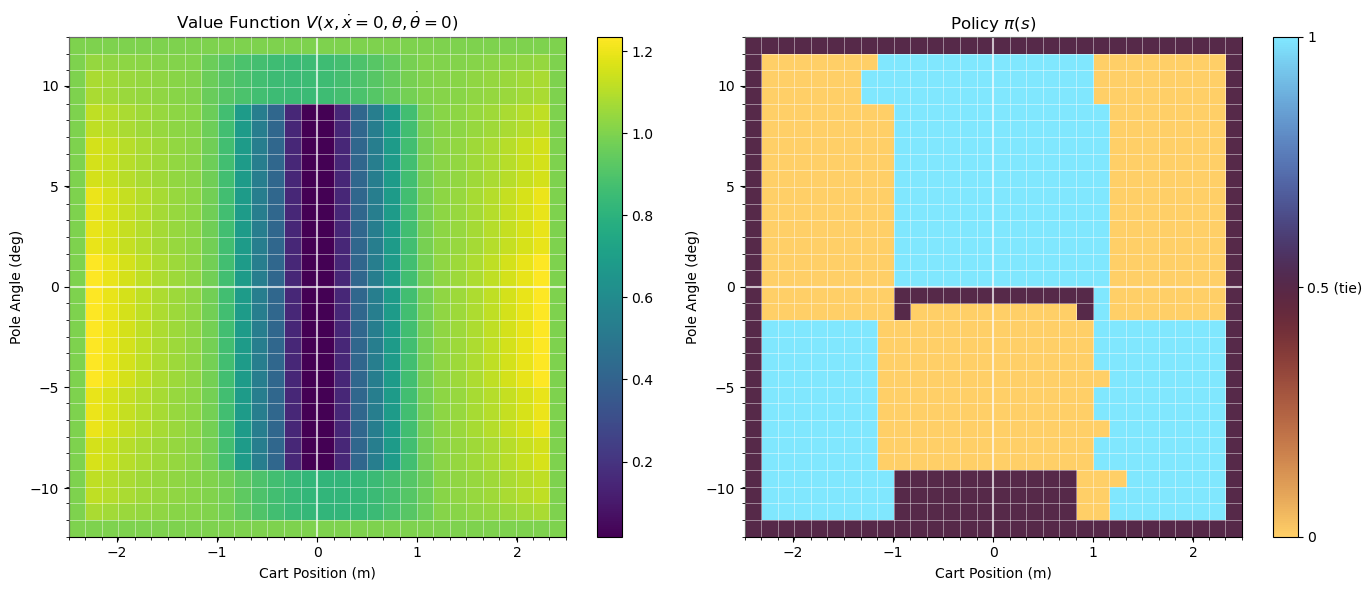

In [7]:
for (c1, c2) in [(0.1, 0.1), (0.01, 0.01)]:
    print(f"\n--- c1 = {c1}, c2 = {c2} ---")
    # Edit quadratic_cost in common.py to use these values
    V = value_iteration(c1,c2,GAMMA=0.99)
    policy = compute_policy(V, GAMMA=0.99)
    plot_policy_value(policy, V, N_BINS, x_vals, theta_vals)

### Answer 1(b)
_Write your explanation here._

# Problem 1(c) – 90° Termination Boundary

In [10]:
# Ensure THETA_LIMIT = np.deg2rad(90) in hyperparameters/common
# Optionally increase N_BINS for finer resolution
V = value_iteration(GAMMA=0.99)
policy = compute_policy(V, GAMMA=0.99)
plot_policy_value(policy, V, N_BINS, x_vals, theta_vals)

KeyboardInterrupt: 

### Answer 1(c)
_Write your explanation here._